# Installations

In [1]:
%pip install fasttext fasttext-wheel
%pip install fasttext-numpy2
%pip install datasets
%pip install sentence-transformers
%pip install umap-learn
%pip install hdbscan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 7.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 44.0 MB/s eta 0:00:00
Using cached pybind11-3.0.2-py3-none-any.whl (310 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4647418 sha256=d146acd17e9197decec8419088c796040b2ea2cc92ceff9077ce3fbabde526e1
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 90.3 MB/s eta 0:00:00


# Imports

In [2]:
import fasttext
import urllib.request
import os
#--------------------------------
from umap import UMAP
from hdbscan import HDBSCAN
#--------------------------------
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
#--------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
#--------------------------------
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# Loading Dataset

In [3]:
dataset = load_dataset("BAAI/IndustryInstruction_Finance-Economics")["train"]

industry_instruction_semantic_cluster_de(…):   0%|          | 0.00/121M [00:00<?, ?B/s]

(…)1%E8%9E%8D_%E7%BB%8F%E6%B5%8E_eval.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/122090 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

------------------

# language detection and filtering

In [4]:
# Downloading the pre-trained language detection model
model_url:str = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz"
model_path:str = "lid.176.ftz"

if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

lang_model = fasttext.load_model(model_path)

In [5]:
en_texts: list[str] = []
min_char_length:int = 300 # Only take detailed answers

for row in tqdm(dataset["conversations"]):
    # 1. Extract the GPT response
    text = next((turn["value"] for turn in row if turn["from"] == "gpt"), "")

    # 2. Stratify by Quality (Length)
    if len(text) > min_char_length:

        # 3. Detect Language (must be '__label__en')
        # We replace newlines because fastText works best on single-line inputs
        prediction = lang_model.predict(text.replace("\n", " "), k=1)
        language = prediction[0][0].replace("__label__", "")
        confidence = prediction[1][0]

        if language == "en" and confidence > 0.8:
            en_texts.append(text)

print(f"Total rows processed: {len(dataset)}")
print(f"Final English High-Quality count: {len(en_texts)}")

100%|██████████| 122090/122090 [00:33<00:00, 3670.73it/s]

Total rows processed: 122090
Final English High-Quality count: 74477


# Embedding the text

In [6]:
# Create an embedding for each abstract
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(en_texts, show_progress_bar=True)

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2328 [00:00<?, ?it/s]

# Reducing dimensionality

In [12]:
# We reduce the input embeddings from 384 dimenions to 5 dimenions
umap_model = UMAP(
    n_components=2,
    min_dist=0.0,
    metric='cosine',
    random_state=42
                )

reduced_embeddings = umap_model.fit_transform(embeddings)

# Clustering the text

In [13]:
from sklearn.cluster import KMeans
import pandas as pd

# Assuming 'reduced_embeddings' is your data
# ---------------------------------------------------------
# 1. Default Parameters
# Standard approach: 8 clusters, k-means++ initialization.
# ---------------------------------------------------------
kmeans_default = KMeans(
    n_clusters=8,
    random_state=42
).fit(reduced_embeddings)


In [14]:
# # Print first three documents in cluster 0
# cluster:int = 0
# for index in np.where(clusters==cluster)[0][:3]:
#     print(en_texts[index][:300] + "... \n ------------------------------ \n")

# Visualizing

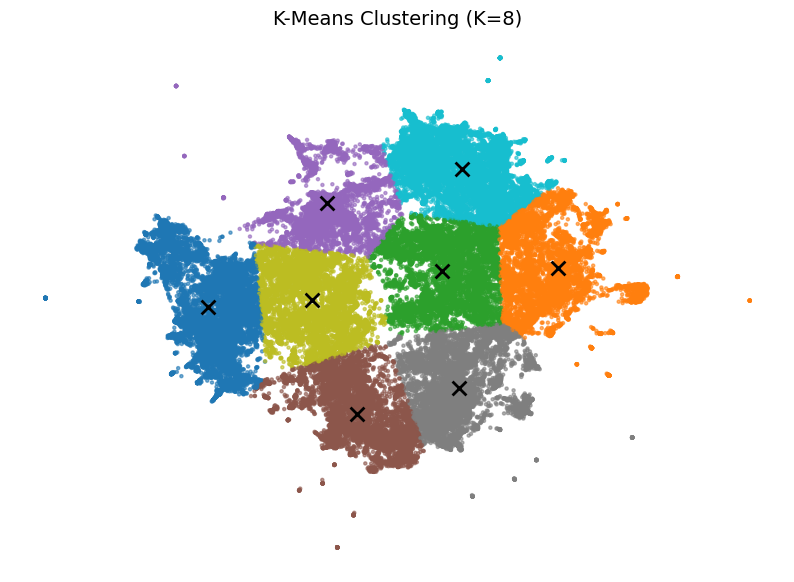

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the data
# Assuming 'reduced_embeddings' is a 2D array (e.g., from UMAP or PCA)
# and 'kmeans_model' has already been .fit()
df = pd.DataFrame(reduced_embeddings, columns=['x', 'y'])
df['cluster'] = kmeans_default.labels_

# 2. Create the plot
plt.figure(figsize=(10, 7))

# Since there is no noise (-1) in K-Means, we plot all points together.
# We use 'tab10' or 'Set1' for clear distinct cluster colors.
scatter = plt.scatter(
    df.x,
    df.y,
    c=df.cluster,
    alpha=0.6,
    s=5,
    cmap='tab10'
)

# 3. Optional: Plot the Centroids
# This is a unique feature of K-Means that helps show the "heart" of each cluster
centroids = kmeans_default.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='x',
    s=100,
    linewidths=2,
    color='black',
    label='Centroids'
)

# 4. Styling and Saving
plt.axis('off')
plt.title(f"K-Means Clustering (K={len(set(df.cluster))})", fontsize=14)
plt.savefig("kmeans_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

# Trying Different Combinations

In [16]:
# ---------------------------------------------------------
# 2. "Granular" Approach (High K)
# Use this if you want to over-segment the data into many small groups.
# ---------------------------------------------------------
kmeans_granular = KMeans(
    n_clusters=25,
    init='k-means++',
    n_init=10,
    max_iter=500,
    random_state=42
).fit(reduced_embeddings)



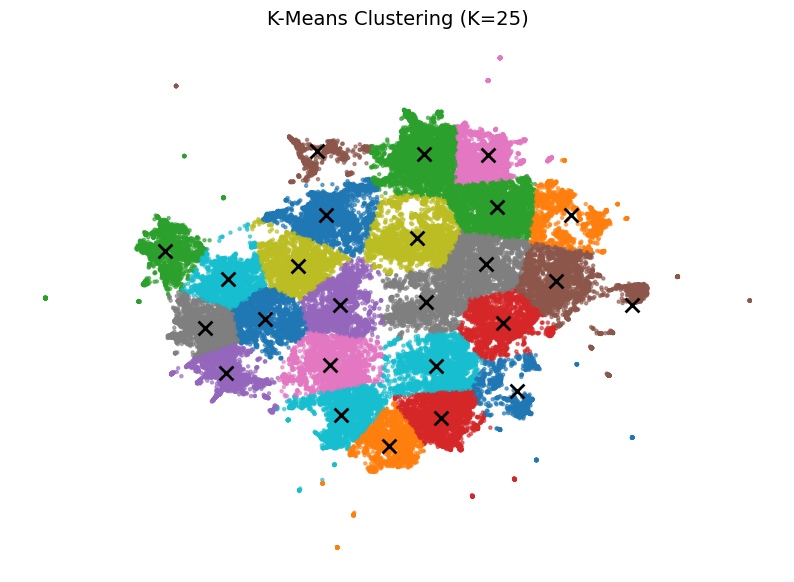

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the data
# Assuming 'reduced_embeddings' is a 2D array (e.g., from UMAP or PCA)
# and 'kmeans_model' has already been .fit()
df = pd.DataFrame(reduced_embeddings, columns=['x', 'y'])
df['cluster'] = kmeans_granular.labels_

# 2. Create the plot
plt.figure(figsize=(10, 7))

# Since there is no noise (-1) in K-Means, we plot all points together.
# We use 'tab10' or 'Set1' for clear distinct cluster colors.
scatter = plt.scatter(
    df.x,
    df.y,
    c=df.cluster,
    alpha=0.6,
    s=5,
    cmap='tab10'
)

# 3. Optional: Plot the Centroids
# This is a unique feature of K-Means that helps show the "heart" of each cluster
centroids = kmeans_granular.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='x',
    s=100,
    linewidths=2,
    color='black',
    label='Centroids'
)

# 4. Styling and Saving
plt.axis('off')
plt.title(f"K-Means Clustering (K={len(set(df.cluster))})", fontsize=14)
plt.savefig("kmeans_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# ---------------------------------------------------------
# 3. "Fast/Bulk" Approach (Random Init)
# Useful for very large datasets where you want a quick,
# less precise grouping into a few major categories.
# ---------------------------------------------------------
kmeans_bulk = KMeans(
    n_clusters=3,
    init='random',
    n_init=1,
    algorithm='elkan',
    random_state=42
).fit(reduced_embeddings)

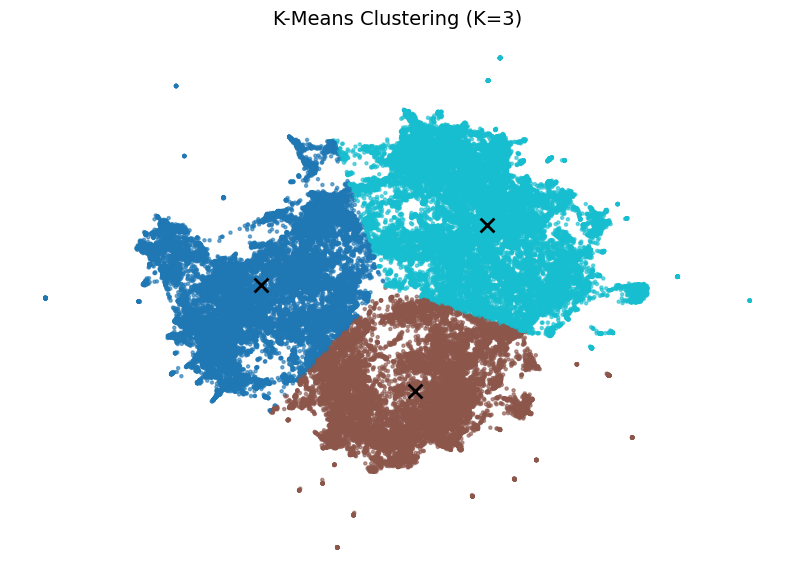

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the data
# Assuming 'reduced_embeddings' is a 2D array (e.g., from UMAP or PCA)
# and 'kmeans_model' has already been .fit()
df = pd.DataFrame(reduced_embeddings, columns=['x', 'y'])
df['cluster'] = kmeans_bulk.labels_

# 2. Create the plot
plt.figure(figsize=(10, 7))

# Since there is no noise (-1) in K-Means, we plot all points together.
# We use 'tab10' or 'Set1' for clear distinct cluster colors.
scatter = plt.scatter(
    df.x,
    df.y,
    c=df.cluster,
    alpha=0.6,
    s=5,
    cmap='tab10'
)

# 3. Optional: Plot the Centroids
# This is a unique feature of K-Means that helps show the "heart" of each cluster
centroids = kmeans_bulk.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='x',
    s=100,
    linewidths=2,
    color='black',
    label='Centroids'
)

# 4. Styling and Saving
plt.axis('off')
plt.title(f"K-Means Clustering (K={len(set(df.cluster))})", fontsize=14)
plt.savefig("kmeans_clusters.png", dpi=300, bbox_inches='tight')
plt.show()